# Caricamento dataset e import librerie

In [ ]:
!pip install tensorflow
!pip install keras
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install sklearn

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Copia lo zip da Drive alla memoria locale di Colab
!cp /content/drive/MyDrive/ProgettoDL/data/original/FER2013.zip /content/

# Estrai il contenuto nella cartella locale /content/FER2013
!unzip -q /content/FER2013.zip -d /content/FER2013

cp: cannot stat '/content/drive/MyDrive/ProgettoDL/data/original/FER2013.zip': No such file or directory
unzip:  cannot find or open /content/FER2013.zip, /content/FER2013.zip.zip or /content/FER2013.zip.ZIP.


### Split Training Data into Training and Validation Sets

Now that the dataset is unzipped, we'll split the original `train` directory of the FER2013 dataset into new `train` and `validation` subsets. This is crucial for evaluating model performance during training without using the test set.

In [ ]:
import os
import shutil
import random
from google.colab import drive

# 1. MONTA GOOGLE DRIVE
# Questo ti chiederà l'autorizzazione per accedere al tuo Drive
drive.mount('/content/drive')

# Define paths
original_dataset_base = '/content/FER2013' # Rimane invariato se l'originale è su Colab
original_train_path = os.path.join(original_dataset_base, 'train')

# MODIFICA QUI: Salviamo lo split all'interno del tuo My Drive personale
split_dataset_base = '/content/drive/MyDrive/FER2013_split'

new_train_path = os.path.join(split_dataset_base, 'train')
new_validation_path = os.path.join(split_dataset_base, 'validation')

split_ratio = 0.8 # 80% for training, 20% for validation

print(f"Splitting data from: {original_train_path}")
print(f"Creating new training set at: {new_train_path}")
print(f"Creating new validation set at: {new_validation_path}")

# Clean up any previous split directories
if os.path.exists(split_dataset_base):
    print(f"Removing existing directory: {split_dataset_base}")
    shutil.rmtree(split_dataset_base)

# Create new base directories for the split dataset
os.makedirs(new_train_path, exist_ok=True)
os.makedirs(new_validation_path, exist_ok=True)

# Get emotion classes (subdirectories, e.g., '0', '1', ..., '6')
emotion_classes = [d for d in os.listdir(original_train_path) if os.path.isdir(os.path.join(original_train_path, d))]
emotion_classes.sort() # Ensure consistent order

if not emotion_classes:
    raise ValueError(f"No emotion class directories found in {original_train_path}. Please check the dataset structure.")

for emotion_class in emotion_classes:
    class_original_path = os.path.join(original_train_path, emotion_class)
    class_new_train_path = os.path.join(new_train_path, emotion_class)
    class_new_validation_path = os.path.join(new_validation_path, emotion_class)

    # Create class-specific directories in the new split structure
    os.makedirs(class_new_train_path, exist_ok=True)
    os.makedirs(class_new_validation_path, exist_ok=True)

    images = [f for f in os.listdir(class_original_path) if os.path.isfile(os.path.join(class_original_path, f))]
    random.shuffle(images)

    split_index = int(len(images) * split_ratio)
    train_images = images[:split_index]
    validation_images = images[split_index:]

    print(f"   Class '{emotion_class}': {len(train_images)} for training, {len(validation_images)} for validation.")

    # Copy images to new train directory
    for img_name in train_images:
        shutil.copy(os.path.join(class_original_path, img_name), class_new_train_path)

    # Copy images to new validation directory
    for img_name in validation_images:
        shutil.copy(os.path.join(class_original_path, img_name), class_new_validation_path)

print("\nDataset split complete!")
print(f"Training data available at: {new_train_path}")
print(f"Validation data available at: {new_validation_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Splitting data from: /content/FER2013/train
Creating new training set at: /content/drive/MyDrive/FER2013_split/train
Creating new validation set at: /content/drive/MyDrive/FER2013_split/validation
Removing existing directory: /content/drive/MyDrive/FER2013_split


FileNotFoundError: [Errno 2] No such file or directory: '/content/FER2013/train'

### Updating Data Generators to use the Newly Split Dataset

Now we will update the paths in the `ImageDataGenerator` setup to point to the `train` and `validation` folders created in the previous step.

# Modelli convoluzionali

In [ ]:
#@title Caricamento del modello
from google.colab import drive
from keras.models import load_model

# Montiamo il drive (se non è già montato)
drive.mount('/content/drive')

# Carichiamo il modello
modelCNN = load_model('/content/drive/MyDrive/CNN_Model.keras')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


ValueError: File not found: filepath=/content/drive/MyDrive/CNN_Model.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
#@title Modello CNN_01
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from keras.layers import Input, Activation, BatchNormalization, Dense, Dropout, Flatten

input_shape = (48, 48, 1) # Dimensioni di input delle immagini

modelCNN = Sequential([
    Input(shape=input_shape),

    Conv2D(32, (3, 3)),
    Activation('relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3)),
    Activation('relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.35),

    Dense(7, activation='softmax')
])

modelCNN.compile(optimizer='adam',
                loss='CategoricalCrossentropy',
                metrics=['Accuracy', tf.keras.metrics.AUC()])

modelCNN.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_32 (Activation)      │ (None, 46, 46, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_33 (Activation)      │ (None, 21, 21, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 839,431 (3.20 MB)

 Trainable params: 839,239 (3.20 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# --- Data Preparation for Model Training ---
# NOTE: This data preparation code is placed in this cell due to a direct
# instruction to modify ONLY the selected cell. In a typical workflow,
# data loading and preprocessing would usually reside in separate cells
# before the model definition and training.

import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define dataset paths to use the newly split data
# The split was done into /content/FER2013_split/train and /content/FER2013_split/validation
# So, update these paths accordingly.
# base_dir = '/content/drive/MyDrive/ProgettoDL/data' # Old base_dir

train_dir = '/content/FER2013_split/train'       # Updated training directory
validation_dir = '/content/FER2013_split/validation' # Updated validation directory

# Image dimensions and batch size
IMG_HEIGHT = input_shape[0] # Use input_shape defined for the model
IMG_WIDTH = input_shape[1]
BATCH_SIZE = 32 # This can be adjusted based on your system's memory and dataset size

# Data Generators for image loading and preprocessing
# For training, include augmentation to help the model generalize better
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalize pixel values to [0, 1]
    #rotation_range=20,
    #width_shift_range=0.2,
    #height_shift_range=0.2,
    #shear_range=0.2,
    #zoom_range=0.2,
    #horizontal_flip=True,
    #fill_mode='nearest'
)

# For validation, only rescale is typically applied (no augmentation)
validation_datagen = ImageDataGenerator(rescale=1./255)

# Load images from directories using the generators
try:
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        color_mode='grayscale', # Model expects 1 channel input
        class_mode='categorical' # For multi-class classification (7 classes)
    )

    validation_generator = validation_datagen.flow_from_directory(
        validation_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        color_mode='grayscale',
        class_mode='categorical'
    )

    print("\nData Generators created successfully.")

    # Function to extract all data from a generator into NumPy arrays.
    # WARNING: This can be memory-intensive for large datasets. For very large
    # datasets, it's more efficient to pass the generators directly to model.fit()
    def get_all_data_from_generator(generator):
        all_images = []
        all_labels = []
        num_samples = generator.samples
        # Calculate steps to cover all samples exactly once
        steps_per_epoch = num_samples // generator.batch_size
        if num_samples % generator.batch_size != 0:
            steps_per_epoch += 1 # Add one more step if there's a partial batch

        for i in range(steps_per_epoch):
            images, labels = next(generator) # Corrected from generator.next()
            all_images.append(images)
            all_labels.append(labels)
        return np.concatenate(all_images), np.concatenate(all_labels)

    print("Extracting training data from generator...")
    x_train_norm, y_train_cnn = get_all_data_from_generator(train_generator)
    print(f"x_train_norm shape: {x_train_norm.shape}, y_train_cnn shape: {y_train_cnn.shape}")

    print("Extracting validation data from generator...")
    x_val_norm, y_val_cnn = get_all_data_from_generator(validation_generator)
    print(f"x_val_norm shape: {x_val_norm.shape}, y_val_cnn shape: {y_val_cnn.shape}")

    print("\nData preparation complete. Variables x_train_norm, y_train_cnn, x_val_norm, y_val_cnn are ready for training.")

except Exception as e:
    print(f"Error during data preparation: {e}")
    print("Please ensure that the dataset directories exist and contain images, and that the 'base_dir' path is correct.")
    print(f"Expected training directory: {train_dir}")
    print(f"Expected validation directory: {validation_dir}")

# The variables x_train_norm, y_train_cnn, x_val_norm, y_val_cnn are now available for subsequent cells.

Found 22965 images belonging to 7 classes.
Found 5744 images belonging to 7 classes.

Data Generators created successfully.
Extracting training data from generator...
x_train_norm shape: (22965, 48, 48, 1), y_train_cnn shape: (22965, 7)
Extracting validation data from generator...
x_val_norm shape: (5744, 48, 48, 1), y_val_cnn shape: (5744, 7)

Data preparation complete. Variables x_train_norm, y_train_cnn, x_val_norm, y_val_cnn are ready for training.


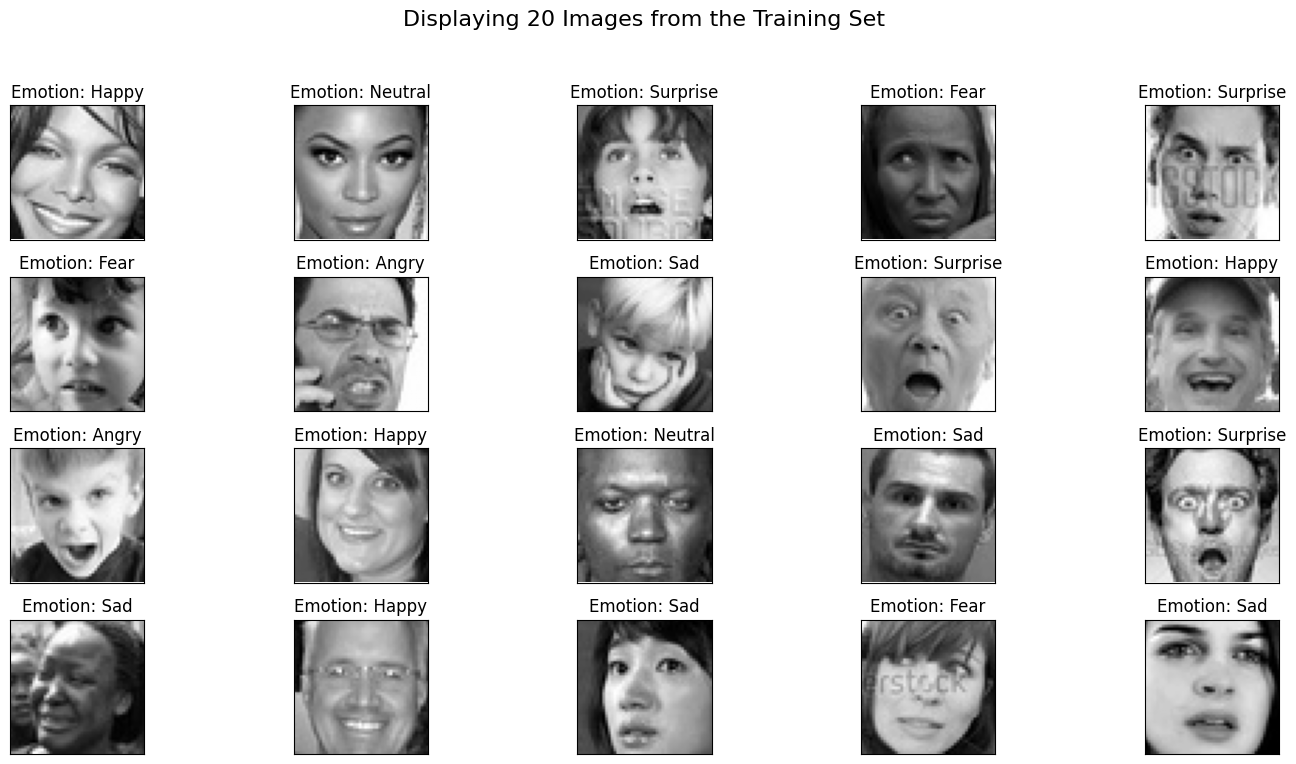

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define the emotion labels based on common FER2013 mapping
emotion_labels = {
    0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy',
    4: 'Neutral', 5: 'Sad', 6: 'Surprise'
}

# Number of images to display
num_images = 20

# Create a figure and subplots
fig = plt.figure(figsize=(15, 8))

for i in range(num_images):
    ax = fig.add_subplot(4, 5, i + 1, xticks=[], yticks=[])

    # Get image and its one-hot encoded label
    image = x_train_norm[i]
    label_one_hot = y_train_cnn[i]

    # Convert one-hot label to class index
    class_index = np.argmax(label_one_hot)

    # Get emotion name
    emotion = emotion_labels.get(class_index, 'Unknown')

    # Reshape the image from (48, 48, 1) to (48, 48) for display
    ax.imshow(image.reshape(IMG_HEIGHT, IMG_WIDTH), cmap='gray')
    ax.set_title(f"Emotion: {emotion}")

plt.suptitle(f'Displaying {num_images} Images from the Training Set', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

In [ ]:
#@title Training del modello - CNN_01

history=modelCNN.fit(x_train_norm, y_train_cnn,
                epochs=15,
                batch_size=8,
                verbose=1,
                validation_data=(x_val_norm, y_val_cnn),
                )

Epoch 1/15
2871/2871 ━━━━━━━━━━━━━━━━━━━━ 75s 26ms/step - Accuracy: 0.2578 - auc_11: 0.6806 - loss: 1.7350 - val_Accuracy: 0.3123 - val_auc_11: 0.7249 - val_loss: 1.6745
Epoch 2/15
2871/2871 ━━━━━━━━━━━━━━━━━━━━ 82s 26ms/step - Accuracy: 0.2871 - auc_11: 0.7035 - loss: 1.6882 - val_Accuracy: 0.3222 - val_auc_11: 0.7296 - val_loss: 1.6563
Epoch 3/15
2871/2871 ━━━━━━━━━━━━━━━━━━━━ 75s 26ms/step - Accuracy: 0.2982 - auc_11: 0.7115 - loss: 1.6686 - val_Accuracy: 0.3541 - val_auc_11: 0.7469 - val_loss: 1.6239
Epoch 4/15
2871/2871 ━━━━━━━━━━━━━━━━━━━━ 75s 26ms/step - Accuracy: 0.2985 - auc_11: 0.7168 - loss: 1.6583 - val_Accuracy: 0.3320 - val_auc_11: 0.7384 - val_loss: 1.6480
Epoch 5/15
2871/2871 ━━━━━━━━━━━━━━━━━━━━ 75s 26ms/step - Accuracy: 0.3110 - auc_11: 0.7201 - loss: 1.6472 - val_Accuracy: 0.3075 - val_auc_11: 0.7384 - val_loss: 1.6199
Epoch 6/15
2871/2871 ━━━━━━━━━━━━━━━━━━━━ 75s 26ms/step - Accuracy: 0.3052 - auc_11: 0.7222 - loss: 1.6412 - val_Accuracy: 0.3266 - val_auc_11: 0.7474

In [ ]:
#@title Test del modello + metriche

y_proba_cnn = modelCNN.predict(x_test_norm)[:, 0] # Accede solo alla prima colonna
y_pred_cnn = (y_proba_cnn > 0.5).astype(int) # Valore di soglia

show_metrics(y_test, y_pred_cnn, y_proba_cnn)